# 8. Logistic Growth

## Introduction

This notebook complements the book chapter by comparing the plots of the analytical and numerical solutions for the logistic growth model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

## Analytical Solution

The logistic model is defined by the differential equation:
$$
\frac{dN}{dt} = r N \left(1 - \frac{N}{K} \right).
$$
This equation can be solved analytically to obtain:
$$
N(t) = \left[ \frac{1}{K} + \left( \frac{1}{N_0} - \frac{1}{K} \right)e^{-rt} \right]^{-1},
$$
where $N_0$ represents the initial condition.


In [2]:
def modelSolution(t, N0, r, K):
    return 1/(1/K + (1/N0 - 1/K)*np.exp(-r*t))

## Dynamic behavior

Plotting the analytical solution with different parameter sets concurvesthe findings of the steady-state stability analysis:
* The system has two steady states: $0$ and $K$. $N^*=0$ is unstable while $N^*= K$ is stable. 
* Parameter $r$ determines the speed at which solutions converge to the steady state. 
* Solutions with initial condition $0< N_0 < 1/2$ yield sigmoidal curves. Otherwise, the curves are monotonic. 

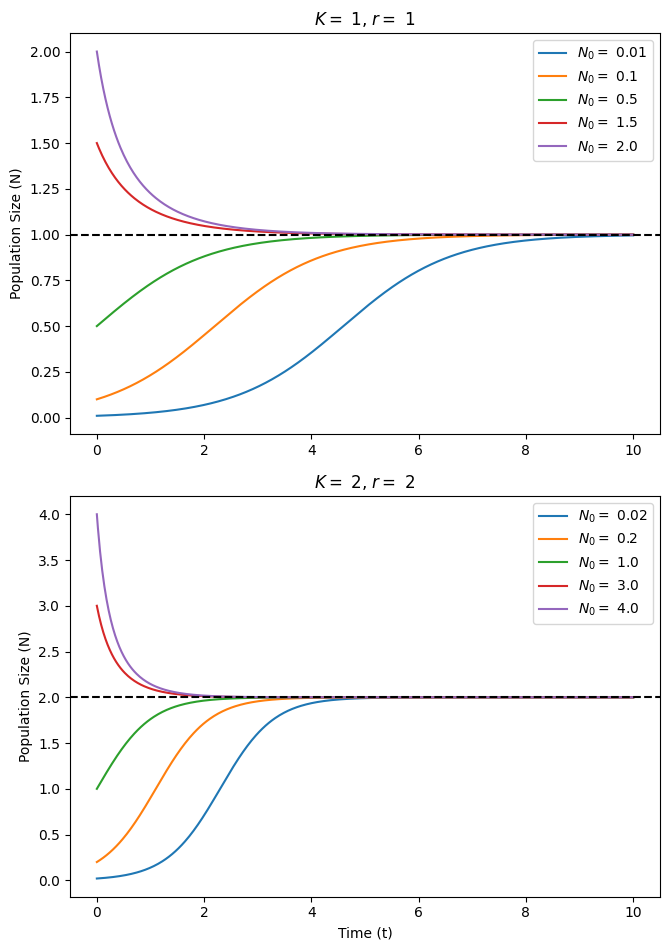

In [9]:
fig, ax =  plt.subplots(nrows=2, ncols=1, figsize=(6.8,9.6))

t = np.linspace(0, 10, 500)

r = 1
K = 1
N0s = np.array([0.01, 0.1, 0.5, 1.5, 2])*K
for N0 in N0s:
    N = modelSolution(t, N0, r, K)
    ax[0].plot(t, N, label=rf"$N_0 =$ {N0}")
ax[0].axhline(y = K, color = 'k', linestyle = '--')
#ax[0].set_xlabel("Time (t)")
ax[0].set_ylabel("Population Size (N)")
ax[0].set_title(rf"$K=$ {K}, $r=$ {r}")
ax[0].legend()

r = 2
K = 2
N0s = np.array([0.01, 0.1, 0.5, 1.5, 2])*K
for N0 in N0s:
    N = modelSolution(t, N0, r, K)
    ax[1].plot(t, N, label=rf"$N_0 =$ {N0}")
ax[1].axhline(y = K, color = 'k', linestyle = '--')
ax[1].set_xlabel("Time (t)")
ax[1].set_ylabel("Population Size (N)")
ax[1].set_title(rf"$K=$ {K}, $r=$ {r}")
ax[1].legend()

fig.tight_layout()

## Numerical Solution

Numerical solutions of the logistic model can accurately reproduce the analytical results, provided that the time step is sufficiently small.

In [10]:
def modelODE(N, t, r, K):
    return r*N*(1-N/K)

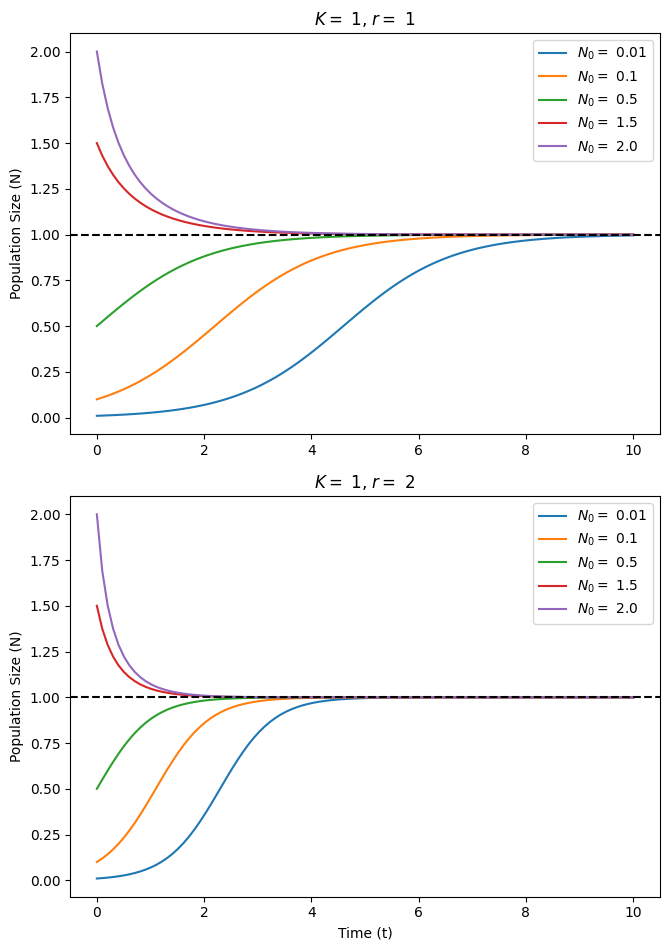

In [11]:
fig, ax =  plt.subplots(nrows=2, ncols=1, figsize=(6.8,9.6))

t = np.linspace(0, 10, 100)


r = 1
K = 1
N0s = np.array([0.01, 0.1, 0.5, 1.5, 2])*K
for N0 in N0s:
    N = odeint(modelODE, N0, t, args=(r, K))
    ax[0].plot(t, N, label=rf"$N_0 =$ {N0}")
ax[0].axhline(y = K, color = 'k', linestyle = '--')
#ax[0].set_xlabel("Time (t)")
ax[0].set_ylabel("Population Size (N)")
ax[0].set_title(rf"$K=$ {K}, $r=$ {r}")
ax[0].legend(loc='upper right')

r = 2
K = 1
N0s = np.array([0.01, 0.1, 0.5, 1.5, 2])*K
for N0 in N0s:
    N = odeint(modelODE, N0, t, args=(r, K))
    ax[1].plot(t, N, label=rf"$N_0 =$ {N0}")
ax[1].axhline(y = K, color = 'k', linestyle = '--')
ax[1].set_xlabel("Time (t)")
ax[1].set_ylabel("Population Size (N)")
ax[1].set_title(rf"$K=$ {K}, $r=$ {r}")
ax[1].legend(loc='upper right')

fig.tight_layout()

## Including a Death Rate

In this section, we explore the consequences of adding a linear mortality term, $-\gamma N$, to the logistic model.

In [12]:
def modelODE_bis(N, t, r, K, gamma):
    return r*N*(1-N/K) - gamma*N

## Steady-State Analysis

Below, we plot the right-hand side of the ODE for the modified model:
$$
f(N) = r N \left(1 - \frac{N}{K} \right) - \gamma N.
$$
Observe that for small values of $\gamma$, we retain the behavior previously studied: there are two steady states, one stable ($N^* > 0$) and one unstable ($N^* = 0$). As $\gamma$ increases, the stable steady state approaches the unstable one until they collide at $\gamma = r$. Beyond this threshold, the steady state $N^* = 0$ becomes stable.

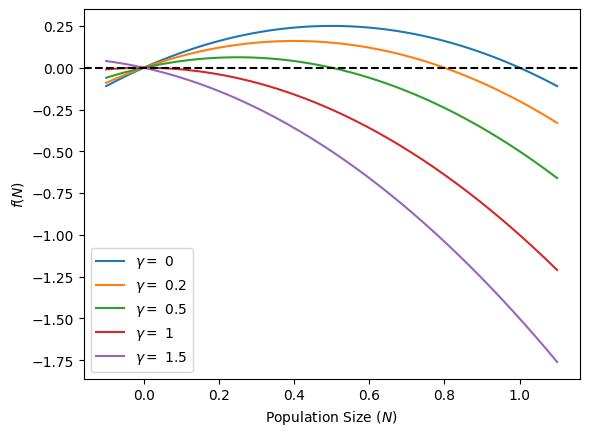

In [13]:
r = 1
K = 1
t = 0

N = np.linspace(-0.1, 1.1, 200)

fig, ax =  plt.subplots()

gammas = [0, 0.2, 0.5, 1, 1.5]

for gamma in gammas:
    f = modelODE_bis(N, t, r, K, gamma)
    ax.plot(N, f, label=rf"$\gamma =$ {gamma}")

ax.axhline(y = 0, color = 'k', linestyle = '--') 

ax.set_xlabel(r"Population Size ($N$)")
ax.set_ylabel(r"$f(N)$")
ax.legend()

## Numerical Solutions

Numerical solutions of the modified model confirm that $r$ acts as a critical upper bound for the parameter $\gamma$ to prevent the extinction of the population.

This observation reveals a bifurcation. This concept is a central theme in nonlinear dynamics and will be examined in greater detail in subsequent chapters.

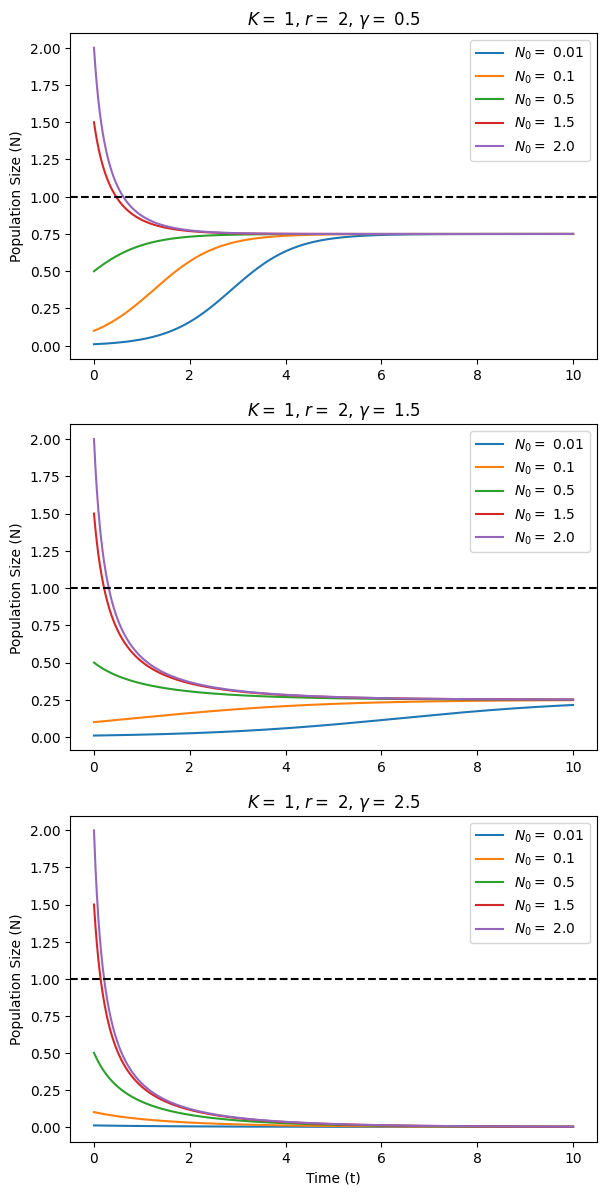

In [16]:
fig, ax =  plt.subplots(nrows=3, ncols=1, figsize=(6.8,4.8*3))

t = np.linspace(0, 10, 1000)
r = 2
K = 1
N0s = np.array([0.01, 0.1, 0.5, 1.5, 2])*K

gamma = 0.5
for N0 in N0s:
    N = odeint(modelODE_bis, N0, t, args=(r, K, gamma))
    ax[0].plot(t, N, label=rf"$N_0 =$ {N0}")
ax[0].axhline(y = 1, color = 'k', linestyle = '--')
#ax[0].set_xlabel("Time (t)")
ax[0].set_ylabel("Population Size (N)")
ax[0].set_title(rf"$K=$ {K}, $r=$ {r}, $\gamma=$ {gamma}")
ax[0].legend()

gamma = 1.5
for N0 in N0s:
    N = odeint(modelODE_bis, N0, t, args=(r, K, gamma))
    ax[1].plot(t, N, label=rf"$N_0 =$ {N0}")
ax[1].axhline(y = 1, color = 'k', linestyle = '--')
#ax[1].set_xlabel("Time (t)")
ax[1].set_ylabel("Population Size (N)")
ax[1].set_title(rf"$K=$ {K}, $r=$ {r}, $\gamma=$ {gamma}")
ax[1].legend()

gamma = 2.5
for N0 in N0s:
    N = odeint(modelODE_bis, N0, t, args=(r, K, gamma))
    ax[2].plot(t, N, label=rf"$N_0 =$ {N0}")
ax[2].axhline(y = 1, color = 'k', linestyle = '--')
ax[2].set_xlabel("Time (t)")
ax[2].set_ylabel("Population Size (N)")
ax[2].set_title(rf"$K=$ {K}, $r=$ {r}, $\gamma=$ {gamma}")
ax[2].legend()